# SVM with scikit-learn

`SVC` with linear, RBF, and polynomial kernels — GridSearchCV, decision boundaries,
support vector visualisation, kernel comparison.

**Dataset:** Breast Cancer  
**Model saved to:** `../Models/svm_sklearn.joblib`

## 1. Load & Split

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

data        = load_breast_cancer()
X_raw, y    = data.data, data.target
class_names = list(data.target_names)
features    = list(data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 455  |  Test: 114


## 2. Baseline — Linear SVC

In [2]:
pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',   SVC(kernel='linear', C=1.0, probability=True, random_state=42))
]).fit(X_train, y_train)

y_pred  = pipe_linear.predict(X_test)
y_proba = pipe_linear.predict_proba(X_test)[:, 1]

print(f"Linear SVM | Accuracy: {accuracy_score(y_test, y_pred):.4f} "
      f"| ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Support vectors: {pipe_linear['svm'].n_support_} (neg, pos)")

Linear SVM | Accuracy: 0.9737 | ROC-AUC: 0.9964
Support vectors: [15 17] (neg, pos)


## 3. Kernel Comparison — Linear, RBF, Polynomial

In [3]:
kernel_results = []

configs = [
    ('Linear',      SVC(kernel='linear',  C=1.0,                  probability=True, random_state=42)),
    ('RBF',         SVC(kernel='rbf',     C=1.0, gamma='scale',   probability=True, random_state=42)),
    ('Polynomial',  SVC(kernel='poly',    C=1.0, degree=3,        probability=True, random_state=42)),
    ('Sigmoid',     SVC(kernel='sigmoid', C=1.0,                  probability=True, random_state=42)),
]

for name, svm in configs:
    pipe = Pipeline([('sc', StandardScaler()), ('svm', svm)]).fit(X_train, y_train)
    yp   = pipe.predict(X_test)
    ya   = pipe.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, yp)
    auc  = roc_auc_score(y_test, ya)
    n_sv = pipe['svm'].n_support_.sum()
    print(f"{name:<12} | Acc: {acc:.4f} | AUC: {auc:.4f} | SVs: {n_sv}")
    kernel_results.append(dict(Kernel=name, Accuracy=round(acc,4),
                               ROC_AUC=round(auc,4), Support_Vectors=n_sv))

pd.DataFrame(kernel_results).set_index('Kernel')

Linear       | Acc: 0.9737 | AUC: 0.9964 | SVs: 32
RBF          | Acc: 0.9825 | AUC: 0.9950 | SVs: 97
Polynomial   | Acc: 0.9123 | AUC: 0.9954 | SVs: 145
Sigmoid      | Acc: 0.9298 | AUC: 0.9907 | SVs: 66


,Accuracy,ROC_AUC,Support_Vectors
Kernel,,,
Linear,0.9737,0.9964,32
RBF,0.9825,0.9950,97
Polynomial,0.9123,0.9954,145
Sigmoid,0.9298,0.9907,66


## 4. GridSearchCV — Best C and Gamma (RBF)

In [4]:
param_grid = {
    'svm__C':     [0.01, 0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}
pipe_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',   SVC(kernel='rbf', probability=True, random_state=42))
])

gs = GridSearchCV(pipe_rbf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_train, y_train)

print(f"Best params : {gs.best_params_}")
print(f"Best CV acc : {gs.best_score_:.4f}")
print(f"Test acc    : {accuracy_score(y_test, gs.best_estimator_.predict(X_test)):.4f}")

Best params : {'svm__C': 10, 'svm__gamma': 0.01}
Best CV acc : 0.9802
Test acc    : 0.9825


## 5. Classification Report & Confusion Matrix (Best Model)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

ROC-AUC: 0.9977


KeyError: 'svm__kernel'

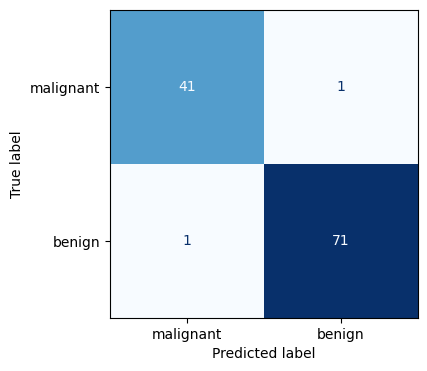

In [5]:
best_model = gs.best_estimator_
y_pred_best  = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best, target_names=class_names))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

cm   = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — Best SVM ({gs.best_params_["svm__kernel"]})')
plt.tight_layout(); plt.show()

## 6. Decision Boundary & Support Vectors (2D PCA Projection)

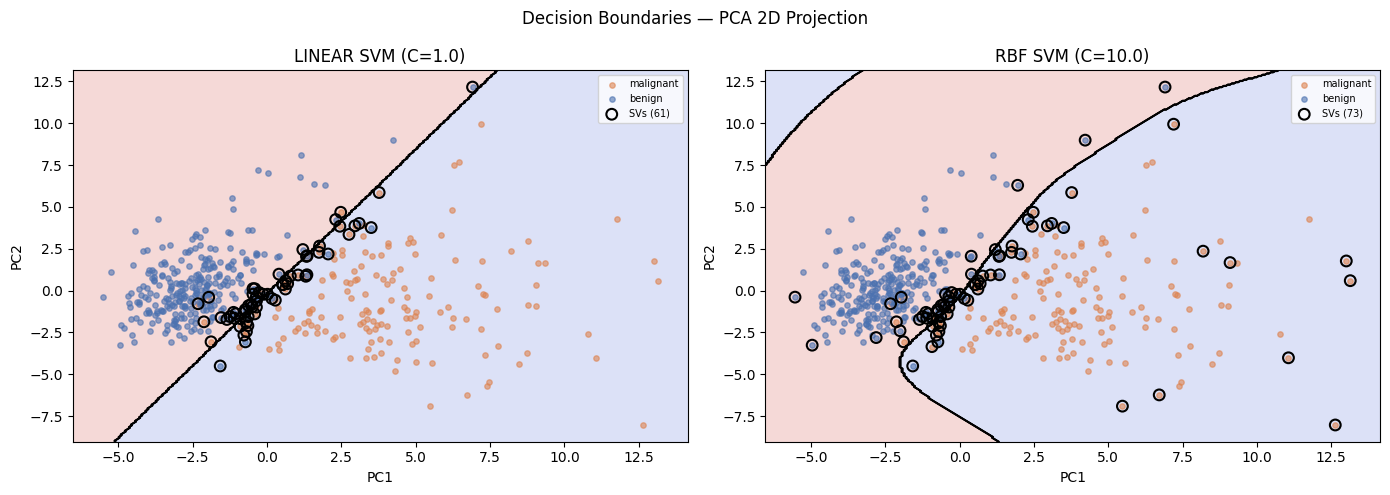

In [6]:
from sklearn.decomposition import PCA

scaler_2d = StandardScaler().fit(X_train)
X_tr_sc   = scaler_2d.transform(X_train)
X_te_sc   = scaler_2d.transform(X_test)

pca   = PCA(n_components=2).fit(X_tr_sc)
X2_tr = pca.transform(X_tr_sc)
X2_te = pca.transform(X_te_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (kernel, C_val) in zip(axes, [('linear', 1.0), ('rbf', 10.0)]):
    svm2 = SVC(kernel=kernel, C=C_val, gamma='scale').fit(X2_tr, y_train)

    x_min, x_max = X2_tr[:,0].min()-1, X2_tr[:,0].max()+1
    y_min, y_max = X2_tr[:,1].min()-1, X2_tr[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = svm2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='k', linewidths=0.8)

    for cls, col, name in zip([0,1], ['#DD8452','#4C72B0'], class_names):
        mask = y_train == cls
        ax.scatter(X2_tr[mask,0], X2_tr[mask,1], c=col, s=15, alpha=0.6, label=name)

    # Support vectors
    sv = svm2.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=60, facecolors='none',
               edgecolors='black', linewidths=1.5, label=f'SVs ({len(sv)})')

    ax.set_title(f'{kernel.upper()} SVM (C={C_val})')
    ax.legend(fontsize=7); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('Decision Boundaries — PCA 2D Projection', fontsize=12)
plt.tight_layout(); plt.show()

## 7. C Sweep — Margin vs Accuracy

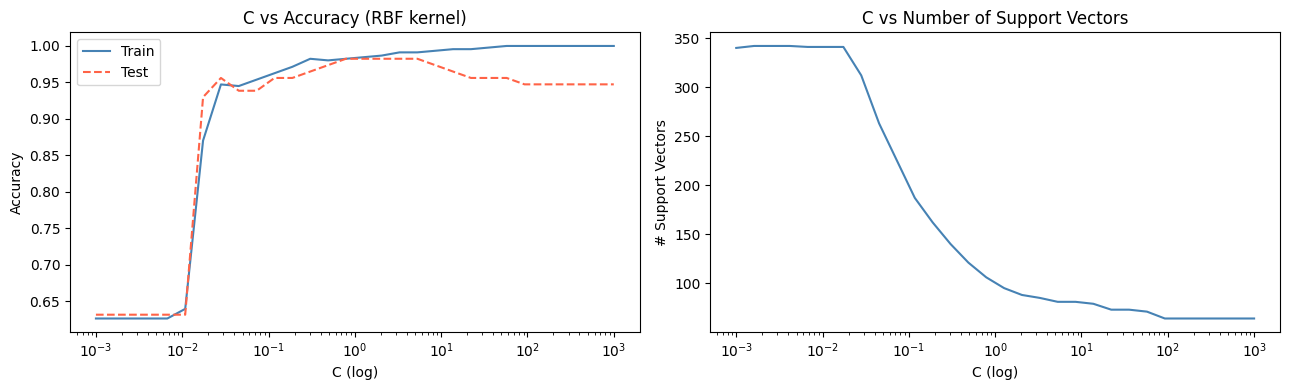

In [7]:
C_vals = np.logspace(-3, 3, 30)
tr_accs, te_accs, n_svs = [], [], []

for c in C_vals:
    p = Pipeline([('sc', StandardScaler()),
                  ('svm', SVC(kernel='rbf', C=c, gamma='scale', random_state=42))])
    p.fit(X_train, y_train)
    tr_accs.append(accuracy_score(y_train, p.predict(X_train)))
    te_accs.append(accuracy_score(y_test,  p.predict(X_test)))
    n_svs.append(p['svm'].n_support_.sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.semilogx(C_vals, tr_accs, label='Train', color='steelblue')
ax1.semilogx(C_vals, te_accs, label='Test',  color='tomato', linestyle='--')
ax1.set_xlabel('C (log)'); ax1.set_ylabel('Accuracy')
ax1.set_title('C vs Accuracy (RBF kernel)'); ax1.legend()

ax2.semilogx(C_vals, n_svs, color='steelblue')
ax2.set_xlabel('C (log)'); ax2.set_ylabel('# Support Vectors')
ax2.set_title('C vs Number of Support Vectors')
plt.tight_layout(); plt.show()

## 8. ROC Curves — All Kernels

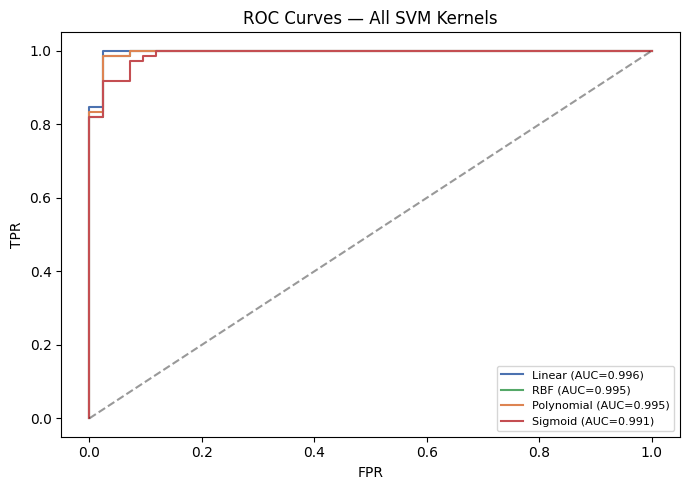

In [8]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))
colors = ['#4C72B0','#55A868','#DD8452','#C44E52']

for (name, svm), col in zip(configs, colors):
    pipe = Pipeline([('sc', StandardScaler()), ('svm', svm)])
    pipe.fit(X_train, y_train)
    ya  = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, ya)
    auc = roc_auc_score(y_test, ya)
    plt.plot(fpr, tpr, color=col, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves — All SVM Kernels')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 9. Save Model to `../Models/`

In [9]:
os.makedirs('../Models', exist_ok=True)

save_path = '../Models/svm_sklearn.joblib'
joblib.dump(best_model, save_path)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")
print(f"Kernel: {best_model['svm'].kernel}  "
      f"C: {best_model['svm'].C}  "
      f"SVs: {best_model['svm'].n_support_}")

Saved → ../Models/svm_sklearn.joblib  (15.9 KB)
Kernel: rbf  C: 10  SVs: [25 27]
